# Position Controller Tuning

**Speed controller** (tuned in `speed_tuning.ipynb`): Kp_v=9, Ki_v=4, Kp_w=3, Ki_w=15

**Parameters to tune here:**
- `Kp_lin` — proportional gain mapping distance error → v_ref
- `Kp_ang` — proportional gain mapping heading error → ω_ref

The tuning follows the same sequential approach:
1. **Kp_lin sweep** — understand the linear gain effect, choose Kp_lin
2. **Kp_ang sweep** — understand the angular gain effect, choose Kp_ang


## Setup

In [21]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from lib.data.dataplot import *
from lib.utils.time import *
from src.robot import RobotModel
from src.controllers import SpeedController, PositionController
from lib.system.polar import *
from lib.system.trajectory import *

# ── Robot physical parameters ──────────────────────────────────────────────
M    = 1.5
r    = 0.14
b    = 0.8
beta = 0.7
WB   = 0.25

F_MAX = 20.0   # N
T_MAX = 10.0   # N·m

DT    = 0.01   # s
T_SIM = 6.0    # s

# ── Tuned speed gains (from speed_tuning.ipynb) ────────────────────────────
KP_V = 9.0;  KI_V = 4.0
KP_W = 3.0;  KI_W = 15.0

# ── Virtual robot profile ──────────────────────────────────────────────────
V_MAX = 1.0
W_MAX = 3.14
ACC   = 3.0
DEC   = 3.0

# ── Sweep values and colors ────────────────────────────────────────────────
kp_sweep = [0.2, 0.5, 1.0, 2.0, 5.0]
colors   = ['#891e8b', '#25117f', '#00b0f0', '#70ad47', '#ffc000']

# Path:
# ── Multi-waypoint path ────────────────────────────────────────────────────
START     = (0.0, 0.0, 0.0)          # (x, y, theta)
WAYPOINTS = [(3.0, 0.0),             # straight ahead
             (3.0, 2.0),             # turn left and go up
             (0.0, 2.0)]             # turn left and come back
THRESHOLD = 0.05

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simulation helper

In [22]:
def simulate_position(kp_lin, kp_ang,
                      start=START, waypoints=WAYPOINTS,
                      duration=T_SIM):
    """
    Simulate the full two-layer control on a straight segment.
    Returns three DataPlotter objects: position (x/y), linear speed, angular speed.
    """
    cart       = RobotModel(M, r, b, beta, WB)
    speed_ctrl = SpeedController(cart, KP_V, KI_V, F_MAX, KP_W, KI_W, T_MAX)
    
    pos_ctrl = PositionController(cart, acc=ACC, dec=DEC, threshold=THRESHOLD, 
                                  kp_lin=kp_lin, kp_ang=kp_ang, v_max=V_MAX, w_max=W_MAX)
    
    pos_ctrl.start_path(start_pose=start, waypoints=list(waypoints))

    # DATA PLOTTER:
    traj_dp = DataPlotter()
    traj_dp.set_x('x (m)')
    traj_dp.add_y('robot_y',  'Robot y')

    spd_dp = DataPlotter()
    spd_dp.set_x('time (seconds)')
    spd_dp.add_y('target_v', 'Target v')
    spd_dp.add_y('current_v', 'Current v')
    spd_dp.add_y('virtual_v', 'Virtual v')

    ang_dp = DataPlotter()
    ang_dp.set_x('time (seconds)')
    ang_dp.add_y('target_w', 'Target ω')
    ang_dp.add_y('current_w', 'Current ω')

    t = Time(use_fake_time=True)
    t.start()

    while t.get() < duration:
        t.sleep(DT)
        delta_t = t.elapsed()

        pose = cart.get_pose()

        # pos_ctrl.evaluate() advances the virtual robot and returns (v_ref, w_ref)
        (v_tgt, w_tgt) = pos_ctrl.evaluate(delta_t)

        (f_left, f_right) = speed_ctrl.evaluate(delta_t, v_tgt, w_tgt)
        cart.evaluate(delta_t, f_left, f_right)
        
        vr_speed = (pos_ctrl.path.trajectory.virtual_robot.speed()
                    if pos_ctrl.active else 0.0)
        
        traj_dp.append_x(pose[0])
        traj_dp.append_y('robot_y', pose[1])

        (v, w) = cart.get_speed()
        spd_dp.append_x(t.get())
        spd_dp.append_y('target_v',  v_tgt)
        spd_dp.append_y('current_v', v)
        spd_dp.append_y('virtual_v', vr_speed)

        ang_dp.append_x(t.get())
        ang_dp.append_y('target_w',  w_tgt)
        ang_dp.append_y('current_w', w)

    return traj_dp, spd_dp, ang_dp

---
## 1. Kp_lin sweep

- **Small Kp_lin**: the real robot lags far behind the virtual robot — slow tracking.
- **Large Kp_lin**: the real robot tries to catch up too aggressively — oscillation.


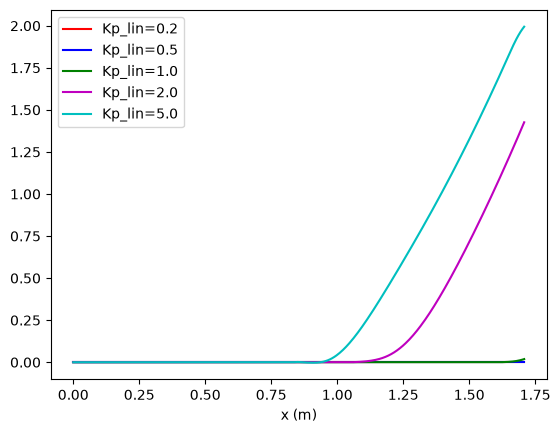

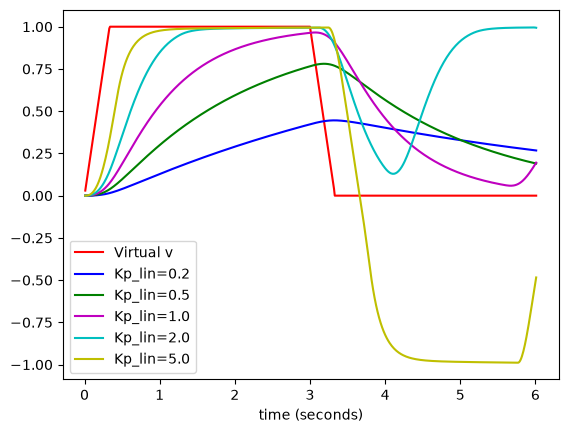

In [ ]:
%matplotlib inline

KP_ANG_FIXED = 3.0

# ── Trajectory plot (x vs y) ───────────────────────────────────────────────
traj_dp = DataPlotter()
traj_dp.set_x('x (m)')

for kp in kp_sweep:
    traj_dp.add_y(f'kp={kp}', f'Kp_lin={kp}')

# ── Speed plot ─────────────────────────────────────────────────────────────
spd_dp = DataPlotter()
spd_dp.set_x('time (seconds)')
spd_dp.add_y('virtual', 'Virtual v')

for kp in kp_sweep:
    spd_dp.add_y(f'kp={kp}', f'Kp_lin={kp}')

# ── Run simulations and fill plotters ─────────────────────────────────────
for kp in kp_sweep:
    tr_dp, s_dp, _ = simulate_position(kp_lin=kp, kp_ang=KP_ANG_FIXED)

    if kp == kp_sweep[0]:                           # fill shared axes once
        traj_dp.x_data           = tr_dp.x_data
        spd_dp.x_data            = s_dp.x_data
        spd_dp.y_data['virtual'] = s_dp.y_data['virtual_v']

    traj_dp.y_data[f'kp={kp}'] = tr_dp.y_data['robot_y']
    spd_dp.y_data[f'kp={kp}']  = s_dp.y_data['current_v']

traj_dp.plot()
spd_dp.plot()

---
## 2. Kp_ang sweep

- **Small Kp_ang**: the robot takes a wide arc to align with the segment.
- **Large Kp_ang**: fast alignment but lateral oscillation visible in the y deviation.


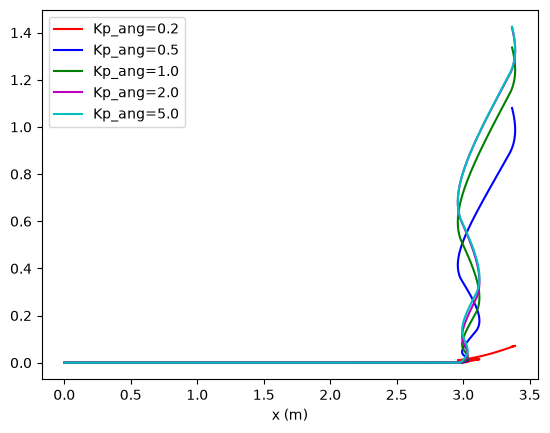

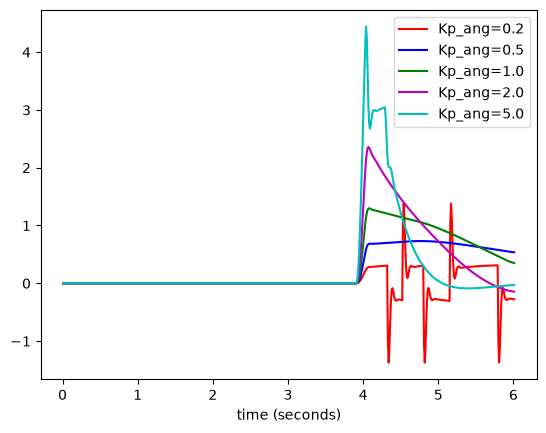

In [26]:
KP_LIN_CHOSEN = 2.0   # ← set your chosen Kp_lin here

# ── Trajectory plot (x vs y) ───────────────────────────────────────────────
traj_dp_w = DataPlotter()
traj_dp_w.set_x('x (m)')

for kp in kp_sweep:
    traj_dp_w.add_y(f'kp={kp}', f'Kp_ang={kp}')

# ── Angular speed plot ─────────────────────────────────────────────────────
ang_dp_w = DataPlotter()
ang_dp_w.set_x('time (seconds)')

for kp in kp_sweep:
    ang_dp_w.add_y(f'kp={kp}', f'Kp_ang={kp}')

# ── Run simulations and fill plotters ─────────────────────────────────────
for kp in kp_sweep:
    tr_dp, _, a_dp = simulate_position(kp_lin=KP_LIN_CHOSEN, kp_ang=kp)

    if kp == kp_sweep[0]:
        traj_dp_w.x_data = tr_dp.x_data
        ang_dp_w.x_data  = a_dp.x_data

    traj_dp_w.y_data[f'kp={kp}'] = tr_dp.y_data['robot_y']
    ang_dp_w.y_data[f'kp={kp}']  = a_dp.y_data['current_w']

traj_dp_w.plot()
ang_dp_w.plot()

---
## Summary — Chosen gains

| Parameter | Value | Effect |
|---|---|---|
| **Kp_lin** | **2.0** | Distance error → v_ref |
| **Kp_ang** | **5.0** | Heading error → ω_ref |